In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import torch
import torch.optim as optim
import torch.nn as nn
from torchviz import make_dot

# Gradient Descent

In [2]:
true_b = 1
true_w = 2
N = 100

np.random.seed(42)
x = np.random.rand(N, 1)
epsilon = (.1 * np.random.randn(N, 1))
y = true_b + true_w * x + epsilon

In [3]:
idx = np.arange(N)
np.random.shuffle(idx)

train_idx = idx[:int(N* .8)]
val_idx = idx[int(N* .8):]

x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

In [4]:
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)
print(b, w)

[0.49671415] [-0.1382643]


In [5]:
yhat = b + w * x_train

In [6]:
error = (yhat - y_train)
loss = (error ** 2).mean()
print(loss)

2.7421577700550976


In [7]:
b_grad = 2 * error.mean()
w_grad = 2 * (x_train * error).mean()
print(b_grad, w_grad)

-3.044811379650508 -1.8337537171510832


In [8]:
lr = 0.1
print(b, w)

b = b - lr * b_grad
w = w - lr * w_grad

print(b, w)

[0.49671415] [-0.1382643]
[0.80119529] [0.04511107]


# Linear Regression in Numpy

In [9]:
# step 0
np.random.seed(42)
b = np.random.randn(1)
w = np.random.randn(1)
print(b, w)

# sets lr
lr = 0.1
n_epochs = 1000
for epoch in range(n_epochs):
    # step 1
    yhat = b + w * x_train
    
    # step 2
    error = (yhat - y_train)
    loss = (error ** 2).mean()

    # step 3
    b_grad = 2 * error.mean()
    w_grad = 2 * (x_train * error).mean()

    # step 4
    b = b - lr * b_grad
    w = w - lr * w_grad

print(b, w)

[0.49671415] [-0.1382643]
[1.02354094] [1.96896411]


In [10]:
# use sklearn
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

[1.02354075] [1.96896447]


# PyTorch

In [11]:
scalar = torch.tensor(3.14159)
vector = torch.tensor([1, 2, 3])
matrix = torch.ones((2, 3), dtype=torch.float)
tensor = torch.randn((2, 3, 4), dtype=torch.float)

print(scalar)
print(vector)
print(matrix)
print(tensor)

tensor(3.1416)
tensor([1, 2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[[-1.4115, -0.4658, -0.7441, -0.9630],
         [-0.6389,  0.6922, -0.2397, -0.5026],
         [-0.6668,  0.9028,  1.0760, -1.9811]],

        [[-1.5484, -0.8560, -1.5342, -0.8988],
         [-1.2249,  0.2491,  1.0820,  2.0232],
         [-0.8043, -1.3436, -1.5840, -1.3715]]])


In [12]:
print(tensor.size(), tensor.shape)

torch.Size([2, 3, 4]) torch.Size([2, 3, 4])


In [13]:
print(scalar.size(), scalar.shape)

torch.Size([]) torch.Size([])


In [14]:
same_matrix = matrix.view(1, 6)
same_matrix[0, 1] = 2
print(matrix)
print(same_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 2., 1., 1., 1., 1.]])


In [15]:
different_matrix = matrix.new_tensor(matrix.view(1, 6))
different_matrix[0, 1] = 3
print(matrix)
print(different_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 3., 1., 1., 1., 1.]])


/var/folders/8n/4tmx7gjx57j_gn5wps411qp40000gn/T/ipykernel_76826/2171686589.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  different_matrix = matrix.new_tensor(matrix.view(1, 6))


In [16]:
# clone method
another_matrix = matrix.view(1, 6).clone().detach()
another_matrix[0, 1] = 4
print(matrix)
print(another_matrix)

tensor([[1., 2., 1.],
        [1., 1., 1.]])
tensor([[1., 4., 1., 1., 1., 1.]])


In [17]:
x_train_tensor = torch.as_tensor(x_train)
x_train.dtype, x_train_tensor.dtype

(dtype('float64'), torch.float64)

In [18]:
float_tensor = x_train_tensor.float()
float_tensor.dtype

torch.float32

In [19]:
dummy_array = np.array([1, 2, 3])
dummy_tensor = torch.as_tensor(dummy_array)
# modifies the numpy array
dummy_array[1] = 0
dummy_tensor

tensor([1, 0, 3])

In [20]:
dummy_tensor.numpy()

array([1, 0, 3])

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [22]:
n_cudas = torch.cuda.device_count()
for i in range(n_cudas):
    print(torch.cuda.get_device_name(i))

In [23]:
gpu_tensor = torch.as_tensor(x_train).to(device)
gpu_tensor[0]

tensor([0.7713], dtype=torch.float64)

In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# data was is in Numpy arrays, but we need transfrom them in to pyorch tensors and then send them to the choosen device
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

In [25]:
# see the difference - notice that .tyoe() is more useful since it also tell us where the tensor is (device)
print(type(x_train), type(x_train_tensor), x_train_tensor.type())

<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.FloatTensor


In [26]:
back_to_numpy = x_train_tensor.cpu().numpy()

In [27]:
# first
# apply gradient descent on these parameters we need to set requires_grad = true
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float)
w = torch.randn(1, requires_grad=True, dtype=torch.float)
print(b, w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


In [28]:
# second
# use GPU
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float).to(device)
w = torch.randn(1, requires_grad=True, dtype=torch.float).to(device)
print(b, w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


In [29]:
# thrid
torch.manual_seed(42)
b = torch.randn(1, dtype=torch.float).to(device)
w = torch.randn(1, dtype=torch.float).to(device)

# set requiring gradients ....
b.requires_grad_()
w.requires_grad_()
print(b, w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


In [30]:
# final
# specify the device at the moment of creation

# step 0 - initializes parameters "b" and "w" randomly
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, \
                dtype=torch.float, device=device)
print(b, w)

tensor([0.3367], requires_grad=True) tensor([0.1288], requires_grad=True)


# Autograd

## backward

In [31]:
# step 1 - computes our model's predicted output - forward pass
yhat = b + w * x_train_tensor

# step 2 - computes the loss
error = (yhat - y_train_tensor)
# use MSE error with regression
loss = (error ** 2).mean()

# step 3 - computes gradients for both "b" and "w" parameters
loss.backward()

In [32]:
print(error.requires_grad, yhat.requires_grad, \
    b.requires_grad, w.requires_grad)
print(y_train_tensor.requires_grad, x_train_tensor.requires_grad)

True True True True
False False


In [33]:
print(b.grad, w.grad)

tensor([-3.1125]) tensor([-1.8156])


In [35]:
b.grad.zero_(), w.grad.zero_()

(tensor([0.]), tensor([0.]))

## updating parameters

In [41]:
# sets lr
lr = 0.1

torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

n_epochs = 1000
for eporch in range(n_epochs):
    yhat = b + w * x_train_tensor

    # loss
    error = (yhat - y_train_tensor)
    loss = (error ** 2).mean()

    # gradient
    loss.backward()

    # updates parameters
    with torch.no_grad():
        b -= lr * b.grad
        w -= lr * w.grad
    b.grad.zero_()
    w.grad.zero_()

print(b, w)

tensor([1.0235], requires_grad=True) tensor([1.9690], requires_grad=True)


# dynamic computation graph

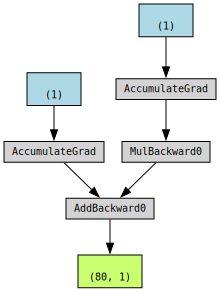

In [43]:
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
yhat = b + w * x_train_tensor
error = (yhat - y_train_tensor)
loss = (error ** 2).mean()
# plot the grah for any variable
make_dot(yhat)

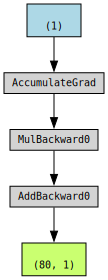

In [44]:
b_nograd = torch.randn(1, requires_grad=False, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
yhat = b_nograd + w * x_train_tensor
make_dot(yhat)

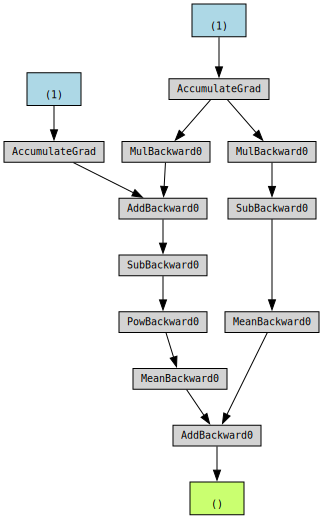

In [45]:
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
yhat = b + w * x_train_tensor
error = yhat - x_train_tensor
loss  = (error ** 2).mean()
if loss > 0:
    yhat2 = w * x_train_tensor
    error2 = yhat2 - y_train_tensor

loss += error2.mean()
make_dot(loss)

# optimizer

## step / zero_grad

In [46]:
optimizer = optim.SGD([b, w], lr=lr)

In [48]:
lr = 0.1

torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

# define SGD optimizer
optimizer = optim.SGD([b, w], lr=lr)

n_epochs = 1000
for epoch in range(n_epochs):
    yhat = b + w * x_train_tensor
    error = (yhat - y_train_tensor)
    loss = (error**2).mean()
    loss.backward()

    optimizer.step() # updating parameters using optimizer
    optimizer.zero_grad() # new gradient zeroing

print(b, w)

tensor([1.0235], requires_grad=True) tensor([1.9690], requires_grad=True)


# loss

In [49]:
# define an MSE loss function
loss_fn = nn.MSELoss(reduction='mean')
loss_fn

MSELoss()

In [54]:
predictions = torch.tensor([0.5, 1.0], dtype=torch.float)
labels = torch.tensor([2.0, 1.3], dtype=torch.float)
loss_fn(predictions, labels)

tensor(1.1700)

In [57]:
lr = 0.1
torch.manual_seed(42)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

optimizer = optim.SGD([b, w], lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

n_epochs = 1000
for epoch in range(n_epochs):
    yhat = b + w * x_train_tensor
    loss = loss_fn(yhat, y_train_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

print(b, w)


tensor([1.0235], requires_grad=True) tensor([1.9690], requires_grad=True)


In [58]:
loss

tensor(0.0080, grad_fn=<MseLossBackward0>)

In [59]:
loss.detach().cpu().numpy()

array(0.00804466, dtype=float32)

In [60]:
print(loss.item(), loss.tolist())

0.008044655434787273 0.008044655434787273


# model

In [61]:
class ManualLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.b = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.w = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x):
        return self.b + self.w * x

## parameters

In [62]:
torch.manual_seed(42)
# create a "dummy" instance of model
dummy = ManualLinearRegression()
list(dummy.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

## stage dict

In [66]:
dummy.state_dict()

OrderedDict([('b', tensor([0.3367])), ('w', tensor([0.1288]))])

In [67]:
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.1,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

In [68]:
torch.manual_seed(42)
dummy = ManualLinearRegression().to(device)

## forward pass

In [70]:
lr = 0.1
torch.manual_seed(42)
model = ManualLinearRegression().to(device)

optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

n_epochs = 1000
for epoch in range(n_epochs):
    model.train()

    # step 1 - computes model's predicted output - forward pass
    yhat = model(x_train_tensor)

    # step 2 - computes loss
    loss = loss_fn(yhat, y_train_tensor)

    # step 3 - computes gradients for both "b" and "w" parameters
    loss.backward()

    # step 4 - updates parameters using gradients and lr
    optimizer.step()
    optimizer.zero_grad()

# inspect its parameters using its state_dict
print(model.state_dict())

OrderedDict([('b', tensor([1.0235])), ('w', tensor([1.9690]))])


In [71]:
linear = nn.Linear(1, 1)
linear

Linear(in_features=1, out_features=1, bias=True)

In [72]:
linear.state_dict()

OrderedDict([('weight', tensor([[-0.2191]])), ('bias', tensor([0.2018]))])

## nested model

In [73]:
class MyLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # custom parameters with linear model
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        self.linear(x)

In [74]:
torch.manual_seed(42)
dummy = MyLinearRegression().to(device)
list(dummy.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [75]:
dummy.state_dict()

OrderedDict([('linear.weight', tensor([[0.7645]])),
             ('linear.bias', tensor([0.8300]))])

## sequential models

In [76]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(1, 1)).to(device)
model.state_dict()

OrderedDict([('0.weight', tensor([[0.7645]])), ('0.bias', tensor([0.8300]))])

In [77]:
torch.manual_seed(42)
model = nn.Sequential(nn.Linear(3, 5),
                      nn.Linear(5, 1)).to(device)
model.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4414,  0.4792, -0.1353],
                      [ 0.5304, -0.1265,  0.1165],
                      [-0.2811,  0.3391,  0.5090],
                      [-0.4236,  0.5018,  0.1081],
                      [ 0.4266,  0.0782,  0.2784]])),
             ('0.bias', tensor([-0.0815,  0.4451,  0.0853, -0.2695,  0.1472])),
             ('1.weight',
              tensor([[-0.2060, -0.0524, -0.1816,  0.2967, -0.3530]])),
             ('1.bias', tensor([-0.2062]))])

In [78]:
torch.manual_seed(42)

model = nn.Sequential()
model.add_module('layer1', nn.Linear(3, 5))
model.add_module('layer2', nn.Linear(5, 1))
model.to(device)

Sequential(
  (layer1): Linear(in_features=3, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

# putting it all together

## data preparation

In [79]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x_train_tensor = torch.as_tensor(x_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

## model configuration

In [80]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 0.1
torch.manual_seed(42)

model = nn.Sequential(nn.Linear(1, 1)).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr)
loss_fn = nn.MSELoss(reduction='mean')

## model training

In [81]:
n_epochs = 1000

for epoch in range(n_epochs):
    model.train()
    yhat = model(x_train_tensor)
    loss = loss_fn(yhat, y_train_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [82]:
print(model.state_dict())

OrderedDict([('0.weight', tensor([[1.9690]])), ('0.bias', tensor([1.0235]))])
